# Fuzzy Regression Discontinuity Design


**🌐 Language:** **English** | [한국어 →](/fuzzy-rdd-ko)

<small><em>Written by Jiwoo Son · <a href="https://github.com/bungaedm">GitHub</a> · <a href="https://www.linkedin.com/in/jiwoo-son-3207021a7/">LinkedIn</a></em></small>


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import warnings

plt.rcParams['axes.unicode_minus'] = False

np.random.seed(2026)
warnings.filterwarnings('ignore')

## Recap. Sharp vs Fuzzy RDD

In the [previous chapter](/rdd-basic-en), we covered the basics of RDD. As a quick recap: RDD comes in two broad flavors, Sharp RDD and Fuzzy RDD, and the previous chapter focused on Sharp RDD. In Sharp RDD, as the formula below shows, the cutoff $c$ **completely** determines treatment assignment.

$$D_i^{\text{Sharp}} = \mathbf{1}[X_i \geq c]$$

For example, if scoring 70 or above on an exam *always* grants the scholarship, and scoring below 70 *never* does, this is a Sharp RDD structure.

In reality, however, such "perfect rules" are rare. Even above 70, a student might not apply for the scholarship, or might be disqualified for missing documents; conversely, someone scoring 69 might still receive it through a special review during the admissions process. When the cutoff has a **discontinuous effect** on the probability of treatment but does not fully determine it, we call this **Fuzzy RDD**.

$$0 \;<\; \lim_{x \rightarrow c+} \Pr(D_i^{\text{Fuzzy}} = 1 \mid X_i = x) \;-\; \lim_{x \rightarrow c-} \Pr(D_i^{\text{Fuzzy}} = 1 \mid X_i = x) \;<\; 1$$

In other words, the probability of treatment jumps discontinuously at the cutoff, but that jump is not a complete jump from 0 to 1.

| | Change at Cutoff | Estimation Method |
|------|--------------|---------|
| **Sharp RDD** | Treatment probability 0% → 100% | OLS (discontinuous regression) |
| **Fuzzy RDD** | Partial jump in treatment probability (e.g., 15% → 65%) | 2SLS (IV) |

In [2]:
def plot_rdd_type():
    c = 0
    R = np.linspace(-3, 3, 300)
    
    D_sharp = np.where(R >= c, 1.0, 0.0)
    
    D_fuzzy = np.where(R >= c,
                       0.65 + 0.1 * np.tanh(R * 2),
                       0.15 + 0.1 * np.tanh(R * 2))
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # ── Sharp RDD ──
    ax = axes[0]
    ax.plot(R[R <  c], D_sharp[R <  c], 'tomato',    linewidth=3, label=r'$P(D=1|R)$: $R < c$')
    ax.plot(R[R >= c], D_sharp[R >= c], 'steelblue', linewidth=3, label=r'$P(D=1|R)$: $R \geq c$')
    ax.axvline(c, color='gray', linestyle=':', linewidth=1.5)
    ax.scatter([c], [0], s=80, color='tomato', zorder=5, edgecolors='tomato', facecolors='none', linewidths=2)
    ax.scatter([c], [1], s=80, zorder=5)
    ax.annotate('', xy=(c, 1.0), xytext=(c, 0.0),
                arrowprops=dict(arrowstyle='<->', color='black', lw=2))
    ax.text(c + 0.1, 0.5, '0 → 1\n(perfect jump)', fontsize=11, va='center', fontweight='bold')
    ax.text(c + 0.05, -0.07, '$c$', fontsize=12, color='gray')
    ax.set_ylim(-0.15, 1.25)
    ax.set_title('Sharp RDD', fontsize=13, fontweight='bold')
    ax.set_xlabel('Running Variable $R$', fontsize=11)
    ax.set_ylabel(r'$P(D=1 \mid R)$', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    # ── Fuzzy RDD ──
    ax = axes[1]
    ax.plot(R[R <  c], D_fuzzy[R <  c], 'tomato',    linewidth=3, label=r'$P(D=1|R)$: $R < c$')
    ax.plot(R[R >= c], D_fuzzy[R >= c], 'steelblue', linewidth=3, label=r'$P(D=1|R)$: $R \geq c$')
    ax.axvline(c, color='gray', linestyle=':', linewidth=1.5)
    
    d_l = np.interp(c - 0.009, R, D_fuzzy)
    d_r = np.interp(c + 0.009, R, D_fuzzy)
    ax.scatter([c], [d_l], s=80, color='tomato', zorder=5, facecolors='none', edgecolors='tomato', linewidths=2)
    ax.scatter([c], [d_r], s=80, zorder=5)
    ax.annotate('', xy=(c, d_r), xytext=(c, d_l),
                arrowprops=dict(arrowstyle='<->', color='black', lw=2))
    ax.text(c + 0.1, (d_l + d_r) / 2,
            f'{d_l:.2f} → {d_r:.2f}\n(partial jump)', fontsize=11, va='center', fontweight='bold')
    ax.text(c + 0.05, -0.07, '$c$', fontsize=12, color='gray')
    ax.set_ylim(-0.15, 1.25)
    ax.set_title('Fuzzy RDD', fontsize=13, fontweight='bold')
    ax.set_xlabel('Running Variable $R$', fontsize=11)
    ax.set_ylabel(r'$P(D=1 \mid R)$', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    fig.suptitle(r'Sharp vs Fuzzy RDD — $P(D=1 \mid R)$', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

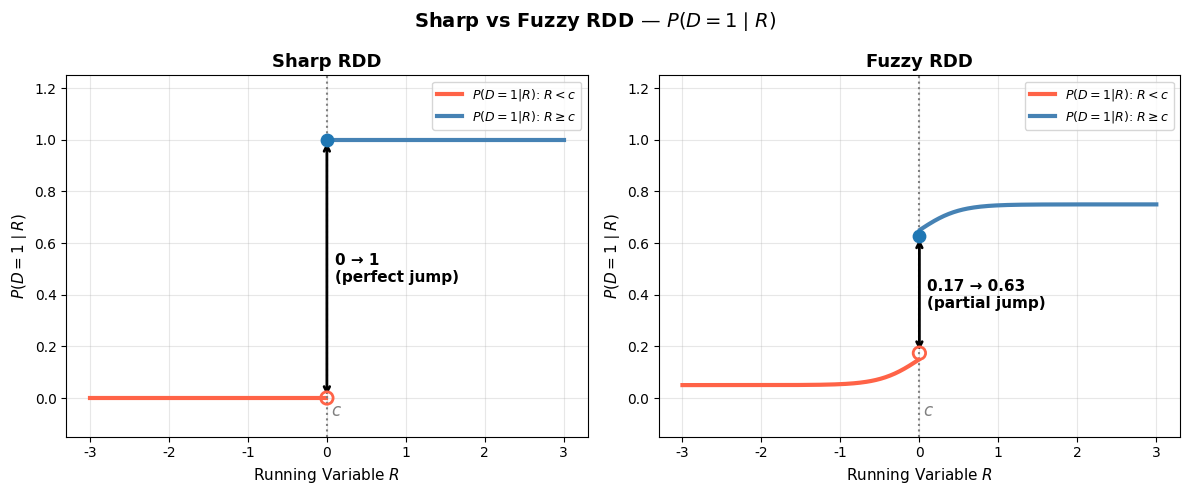

In [3]:
plot_rdd_type()

## 1. What is Fuzzy RDD?

In one sentence, Fuzzy RDD is RDD for situations where the cutoff does not "force" treatment.

For example, suppose a student becomes eligible to **apply** for a scholarship if they score 70 on the exam. Under Sharp RDD, everyone who becomes eligible would receive the scholarship. But in reality:

- A student who scored 71 and became eligible but missed the application window
- A student who scored 72 but was disqualified for incomplete documents
- A student who scored 75 but did not apply because their family is wealthy

Conversely, someone scoring 68 might still receive it through a special review or appeals process.

The cutoff determines **eligibility**, but actual treatment does not necessarily follow from that eligibility. This is the world of Fuzzy RDD.

In this situation, we must distinguish the key variables:

- $X_i$: Exam score (Running variable)
- $Z_i = \mathbf{1}[X_i \geq 70]$: Scholarship **eligibility** (Instrumental variable)
- $D_i$: Actual scholarship **receipt** (Treatment variable)
- $Y_i$: GPA (Outcome variable)

In Sharp RDD, $Z_i = D_i$. In Fuzzy RDD, $Z_i \neq D_i$. $Z_i$ influences $D_i$ but does not fully determine it.

## 2. How Do We Estimate the Effect?

In Sharp RDD, estimating the effect was simple. Students just to the left and right of the cutoff are nearly identical, except one side receives 100% of the treatment and the other receives 0%. So the size of the jump in the outcome ($Y$) at the cutoff *was* the treatment effect.

In Fuzzy RDD, however, a complication arises: crossing the cutoff means only **some** people receive treatment. Let's look at the numbers. Using an exam score cutoff of 70:

- Below the cutoff (score < 70): only 10% receive the scholarship
- At or above the cutoff (score ≥ 70): 65% receive the scholarship

In other words, crossing the cutoff doesn't mean everyone gets treated — the treatment rate jumps from 10% to 65%, a jump of 55 percentage points. If GPA jumps by 0.5 points at the cutoff, that 0.5-point jump was produced not by everyone, but by the "additional 55 percentage points" of recipients.

So what is the effect per person who *actually* received treatment? We simply divide the jump in the outcome by the jump in the treatment rate.

$$\hat{\tau}_{Fuzzy} = \frac{\text{Jump in } Y}{\text{Jump in } D} = \frac{0.5}{0.55} \approx 0.91$$

This is called the **Wald estimator**: dividing the jump in the outcome by the jump in treatment recovers the effect per unit of treatment. Let's name the numerator and denominator:

- **Numerator ($\widehat{\text{ITT}}_Y$)**: the jump in the outcome ($Y$) caused by eligibility ($Z$) — "how much did GPA rise because eligibility was granted?"
- **Denominator ($\widehat{\text{ITT}}_D$)**: the jump in treatment ($D$) caused by eligibility ($Z$) — "how much did the actual receipt rate rise because eligibility was granted?"

$$\hat{\tau}_{Fuzzy} = \frac{\widehat{\text{ITT}}_Y}{\widehat{\text{ITT}}_D}$$

> ITT stands for Intention-To-Treat: it refers to the effect of *being granted eligibility for treatment*, not the effect of actually receiving treatment.

Seen this way, Sharp RDD is just a special case of Fuzzy RDD. If the treatment rate jumps completely from 0% to 100%, the denominator ($\widehat{\text{ITT}}_D$) equals 1, and the jump in $Y$ becomes the effect itself.

## 3. What Does the Estimated Effect Mean?

We just derived "the effect per person who actually came to receive treatment." But a natural question remains: who exactly is this "person who came to receive treatment"?

Here's the key idea. Near the cutoff, people who would have received the scholarship regardless of eligibility (e.g., those receiving it through some other special arrangement), or people who would never receive it even if eligible, are not captured by the Wald estimator. Both the numerator and the denominator only reflect "people whose behavior changed because of eligibility."

The formal term for someone who receives treatment only because they became eligible is a **Complier**. The effect Fuzzy RDD estimates is the effect for these Compliers — more precisely, it is the **LATE** (Local Average Treatment Effect): the treatment effect for Compliers near the cutoff.

Splitting people into four types based on eligibility ($Z$) makes clear who a Complier is.

In [4]:
pd.DataFrame({
    'Type': ['Complier', 'Always-taker', 'Never-taker', 'Defier'],
    'D when Z=0': [0, 1, 0, 1],
    'D when Z=1': [1, 1, 0, 0],
    'Description': [
        'Takes treatment only when eligible \u2190 estimation target',
        'Always takes treatment regardless of eligibility',
        'Never takes treatment even when eligible',
        'Refuses treatment when eligible (excluded by monotonicity assumption)',
    ]
})

,Type,D when Z=0,D when Z=1,Description
0,Complier,0,1,Takes treatment only when eligible ← estimatio...
1,Always-taker,1,1,Always takes treatment regardless of eligibility
2,Never-taker,0,0,Never takes treatment even when eligible
3,Defier,1,0,Refuses treatment when eligible (excluded by m...


We assume there are no **Defiers** — i.e., no one who *refuses* treatment specifically because they became eligible (this is the Monotonicity assumption, covered in detail in the next section). Under this assumption, the effect estimated near the cutoff simplifies cleanly to:

$$\tau^{Fuzzy} = \mathbb{E}[Y_i(1) - Y_i(0) \mid \text{Complier},\; X_i = c]$$

In words: this is the treatment effect, near the cutoff, for people who came to receive treatment because they became eligible (Compliers). Always-takers and Never-takers are not included in this effect — we simply cannot know the effect for people who always, or never, receive treatment regardless of eligibility. This is both a fundamental limitation of Fuzzy RDD and, at the same time, an honest estimate of what we can actually know. To the question "whose effect is this?", we can now answer: the LATE of the Compliers.

## 4. Key Assumptions

So far, we used eligibility ($Z$) as a lever to estimate the effect. In fact, this eligibility indicator $Z_i = \mathbf{1}[X_i \geq c]$ is exactly an **instrumental variable (IV)**. In other words, Fuzzy RDD is fundamentally an instrumental variable estimation problem. For the Wald estimator (= LATE) from Section 2 to be trustworthy, the instrument must be valid — which requires three conditions.

### Relevance

$Z_i$ must have a real effect on $D_i$: becoming eligible must actually raise the probability of treatment. This is equivalent to saying that the **denominator of the Wald estimator ($\widehat{\text{ITT}}_D$) must not be zero** (if it were zero, the division itself would break down).

$$\text{Cov}(Z_i,\, D_i) \neq 0$$

This is checked using the F-statistic from the first-stage regression; conventionally, $F > 10$ indicates a strong instrument.

### Exclusion Restriction

$Z_i$ must affect $Y_i$ **only** through $D_i$. That is, **the mere fact of crossing the score-70 cutoff** must not directly change GPA. GPA should rise because the scholarship was actually received — not simply because eligibility was granted (e.g., if being notified of eligibility itself boosts confidence and raises grades, this would violate the exclusion restriction).

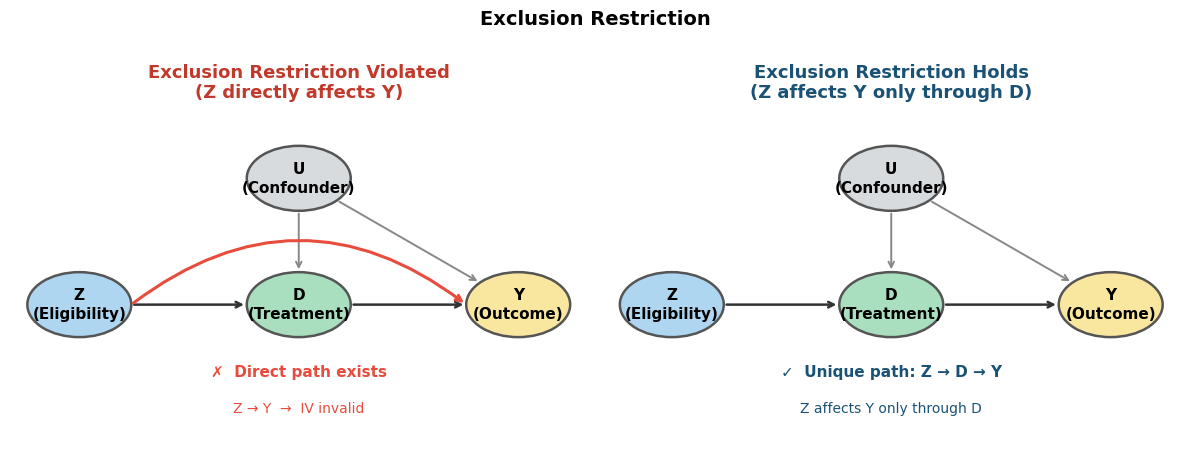

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

pos = {'Z': (0.12, 0.50), 'D': (0.50, 0.50), 'Y': (0.88, 0.50), 'U': (0.50, 0.85)}
node_colors = {'Z': '#AED6F1', 'D': '#A9DFBF', 'Y': '#F9E79F', 'U': '#D7DBDD'}
node_labels = {'Z': 'Z\n(Eligibility)', 'D': 'D\n(Treatment)', 'Y': 'Y\n(Outcome)', 'U': 'U\n(Confounder)'}
R = 0.09

def draw_nodes(ax):
    for name, (x, y) in pos.items():
        circle = plt.Circle((x, y), R, color=node_colors[name], ec='#555', lw=1.8, zorder=3)
        ax.add_patch(circle)
        ax.text(x, y, node_labels[name], ha='center', va='center', fontsize=11,
                fontweight='bold', zorder=4, linespacing=1.3)

def arrow(ax, a, b, color='#333', lw=1.8, rad=0.0, ls='-'):
    x1, y1 = pos[a]; x2, y2 = pos[b]
    dx, dy = x2 - x1, y2 - y1
    dist = (dx**2 + dy**2) ** 0.5
    sx = x1 + R * dx / dist;  sy = y1 + R * dy / dist
    ex = x2 - R * dx / dist;  ey = y2 - R * dy / dist
    style = f'arc3,rad={rad}' if rad != 0 else 'arc3,rad=0'
    ax.annotate('', xy=(ex, ey), xytext=(sx, sy),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw,
                                connectionstyle=style,
                                linestyle=ls))

# ── Left: Exclusion Restriction Violated ──
ax = axes[0]
ax.set_xlim(0, 1); ax.set_ylim(0.1, 1.05); ax.axis('off')
ax.set_title('Exclusion Restriction Violated\n(Z directly affects Y)', fontsize=13, fontweight='bold', color='#C0392B')
draw_nodes(ax)
arrow(ax, 'Z', 'D')
arrow(ax, 'D', 'Y')
arrow(ax, 'U', 'D', color='#888', lw=1.4)
arrow(ax, 'U', 'Y', color='#888', lw=1.4)
arrow(ax, 'Z', 'Y', color='#E74C3C', lw=2.2, rad=-0.38)   # direct path (violation)
# ✗ annotation
mx = (pos['Z'][0] + pos['Y'][0]) / 2
my = min(pos['Z'][1], pos['Y'][1]) - 0.20
ax.text(mx, my, '\u2717  Direct path exists', color='#E74C3C', fontsize=11,
        ha='center', fontweight='bold')
ax.text(mx, my - 0.10, 'Z \u2192 Y  \u2192  IV invalid', color='#E74C3C', fontsize=10, ha='center')

# ── Right: Exclusion Restriction Holds ──
ax2 = axes[1]
ax2.set_xlim(0, 1); ax2.set_ylim(0.1, 1.05); ax2.axis('off')
ax2.set_title('Exclusion Restriction Holds\n(Z affects Y only through D)', fontsize=13, fontweight='bold', color='#1A5276')
draw_nodes(ax2)
arrow(ax2, 'Z', 'D')
arrow(ax2, 'D', 'Y')
arrow(ax2, 'U', 'D', color='#888', lw=1.4)
arrow(ax2, 'U', 'Y', color='#888', lw=1.4)
mx2 = (pos['Z'][0] + pos['Y'][0]) / 2
my2 = min(pos['Z'][1], pos['Y'][1]) - 0.20
ax2.text(mx2, my2, '\u2713  Unique path: Z \u2192 D \u2192 Y', color='#1A5276',
         fontsize=11, ha='center', fontweight='bold')
ax2.text(mx2, my2 - 0.10, 'Z affects Y only through D', color='#1A5276',
         fontsize=10, ha='center')

plt.suptitle('Exclusion Restriction', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Monotonicity

There must be no **Defiers** — i.e., no one who refuses treatment specifically *because* they became eligible. This assumption is what allows us to cleanly interpret the entire increase in treatment at the cutoff as "additional treatment received by Compliers" (this connects directly to the definition of Compliers in Section 3).

$$D_i(Z=1) \geq D_i(Z=0) \quad \forall i$$

---

When these three assumptions (Relevance, Exclusion Restriction, Monotonicity) hold, the Wald estimator $\widehat{\text{ITT}}_Y / \widehat{\text{ITT}}_D$ from Section 2 can be interpreted as the causal effect on Compliers (LATE). In the next section, we look at **2SLS**, the regression-based method for estimating this Wald estimator in practice.

## 5. Estimating with 2SLS

In Section 2, we built intuition for the LATE using the Wald estimator $\widehat{\text{ITT}}_Y / \widehat{\text{ITT}}_D$. In practice, rather than computing this ratio by hand, we use a methodology called **2SLS** (Two-Stage Least Squares). The point estimate from 2SLS is exactly identical to the Wald estimator, with the added benefit that we can properly obtain **standard errors (confidence intervals)**.

To do this, we distinguish three regressions. There are many names, but in the end they are just regression-based ways of obtaining the numerator and denominator from Section 2.

| Name | Path | Estimation Target | Role |
|------|------|-----------|------|
| **Reduced Form** | $Z_i \rightarrow Y_i$ | $\widehat{\text{ITT}}_Y$ | Wald numerator / pre-check |
| **2SLS First Stage** | $Z_i \rightarrow D_i$ | $\widehat{\text{ITT}}_D$ | Wald denominator / instrument strength |
| **2SLS Second Stage** | $\hat{D}_i \rightarrow Y_i$ | $\hat{\beta}_1 = \text{LATE}$ | Final estimate (= equivalent to Wald) |

---

### Reduced Form: $Z_i \rightarrow Y_i$ (= Wald numerator)

$$Y_i = \gamma_0 + \gamma_1 Z_i + \gamma_2(X_i - c) + \gamma_3 Z_i(X_i - c) + \varepsilon_i$$

- **Key coefficient**: $\hat{\gamma}_1 = \widehat{\text{ITT}}_Y$ (the size of the jump in Y at the cutoff)
- **Two roles**
    - **Pre-check**: Before running 2SLS, this confirms whether "eligibility $Z_i$ actually reaches the outcome $Y_i$." If $\hat{\gamma}_1 \approx 0$, that signals there may be no effect at all, and the design should be reconsidered.
    - **Wald numerator**: At the same time, $\hat{\gamma}_1$ is used directly as the numerator of the Wald estimator.

---

### 2SLS: Why Two Stages?

$D_i$ (actual treatment) is an **endogenous variable**. People who received the scholarship may have differed from those who didn't from the start (in ability, motivation, etc.), so regressing $Y_i$ directly on $D_i$ produces bias. 2SLS extracts only the part of $D_i$ that varies **exogenously because of the instrument $Z_i$**, and uses that part to explain $Y_i$.

#### First Stage: $Z_i \rightarrow D_i$ (= Wald denominator)

$$D_i = \alpha_0 + \alpha_1 Z_i + \alpha_2(X_i - c) + \alpha_3 Z_i(X_i - c) + \varepsilon_i^{(1)}$$

- **Key coefficient**: $\hat{\alpha}_1 = \widehat{\text{ITT}}_D$ (the size of the jump in treatment probability at the cutoff)
- **Diagnostic**: F-statistic $\geq 10$ indicates a strong instrument; below 10 signals a weak-instrument problem.
- **Output**: fitted values $\hat{D}_i$ — the "exogenous part of treatment" explained by the instrument

#### Second Stage: $\hat{D}_i \rightarrow Y_i$

$$Y_i = \beta_0 + \beta_1 \hat{D}_i + \beta_2(X_i - c) + \beta_3 \hat{D}_i(X_i - c) + \varepsilon_i^{(2)}$$

- Plugging the first-stage fitted values $\hat{D}_i$ in place of the treatment variable removes the endogeneity and gives a clean estimate of the treatment effect.
- **Key coefficient**: $\hat{\beta}_1$ = **LATE estimate**

---

### In the End, the Two Are the Same

The $\hat{\beta}_1$ from the second stage of 2SLS is exactly equal to the Wald estimator computed by hand in Section 2.

$$\hat{\beta}_1 = \frac{\hat{\gamma}_1}{\hat{\alpha}_1} = \frac{\widehat{\text{ITT}}_Y}{\widehat{\text{ITT}}_D}$$

Going back to our exam-score example: if becoming eligible raises GPA by 0.5 points ($\text{ITT}_Y$) and raises the treatment rate by 55 percentage points ($\text{ITT}_D$), the effect per Complier is $0.5 \div 0.55 \approx 0.91$ points — the same value we found intuitively in Section 2.

> **Note**: Implementing the second stage manually as above gives the correct point estimate ($\hat{\beta}_1$), but the **standard errors are underestimated**. In practice, use an IV estimation package such as `linearmodels` to obtain accurate standard errors.

## 6. Visualization

We visualize the three stages of Fuzzy RDD estimation on one screen. Before looking at the graphs, make sure you understand what each panel contains.

- **Left — Reduced Form (Z → Y)**: A scatter plot of exam score (X) and GPA (Y). Regression lines are fitted on each side of the cutoff, showing how much GPA jumps at the cutoff ($\widehat{\text{ITT}}_Y$ = Wald numerator). This serves as a pre-check to confirm that the instrument actually reaches the outcome before running 2SLS.
- **Center — 2SLS First Stage (Z → D)**: A scatter plot of exam score (X) and actual treatment status (D). This shows how much treatment probability jumps at the cutoff ($\widehat{\text{ITT}}_D$ = Wald denominator) and visually confirms the strength of the instrument.
- **Right — 2SLS Second Stage Result**: The LATE estimated by 2SLS and its 95% confidence interval. The diamond (◆) is the point estimate, the horizontal line is the confidence interval, and the green dashed line is the True LATE set in the simulation.

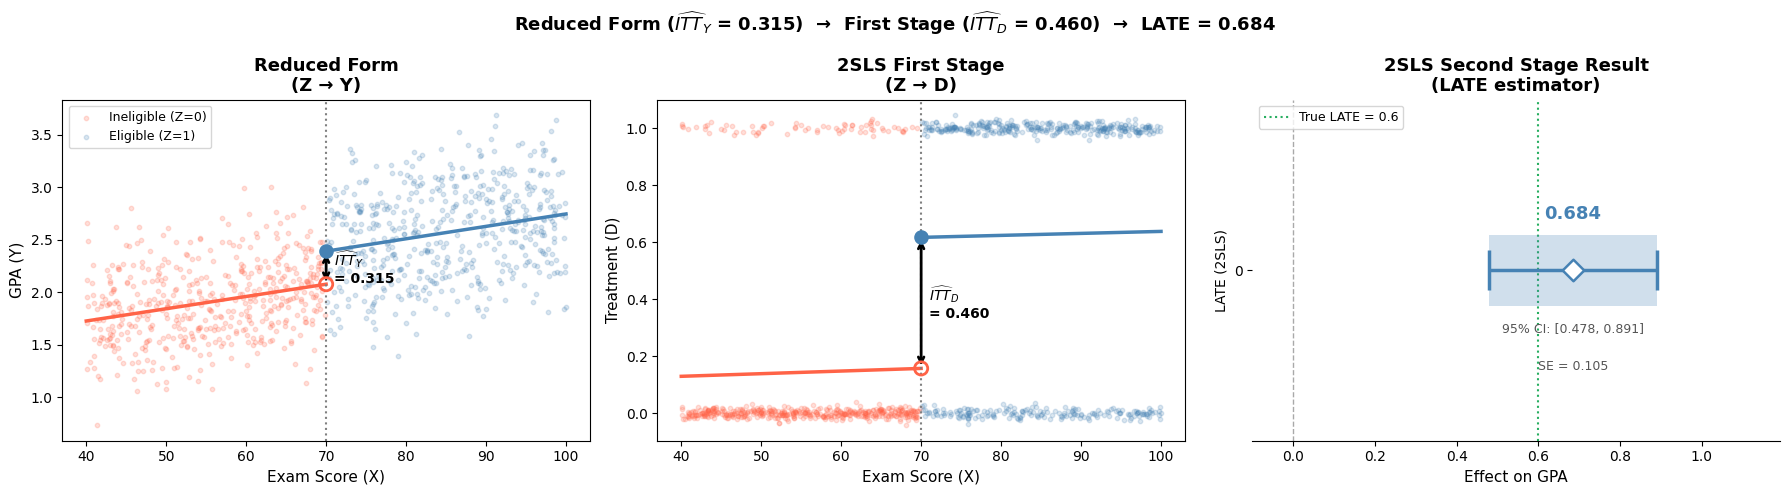

In [6]:
n = 1000
cutoff = 70
true_late = 0.6

score   = np.random.uniform(40, 100, n)
elig    = (score >= cutoff).astype(int)
treated = np.where(elig == 1,
                   np.random.binomial(1, 0.65, n),
                   np.random.binomial(1, 0.15, n))
gpa = (2.0 + 0.012*(score - cutoff)
       + true_late * treated
       + np.random.normal(0, 0.3, n))

df_viz = pd.DataFrame({'score': score, 'elig': elig,
                       'treated': treated, 'gpa': gpa,
                       'score_c': score - cutoff})

# First stage → D_hat
fs_viz = smf.ols('treated ~ elig + score_c + elig:score_c', data=df_viz).fit()
df_viz['D_hat'] = fs_viz.fittedvalues

# Second stage → LATE
ss_viz  = smf.ols('gpa ~ D_hat + score_c + D_hat:score_c', data=df_viz).fit()
LATE    = ss_viz.params['D_hat']
LATE_se = ss_viz.bse['D_hat']
LATE_ci = ss_viz.conf_int().loc['D_hat'].values   # [lower, upper]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
left  = df_viz[df_viz['elig'] == 0]
right = df_viz[df_viz['elig'] == 1]
xs_l  = np.linspace(40, cutoff, 100)
xs_r  = np.linspace(cutoff, 100, 100)

ACCENT = 'steelblue'
GREEN  = '#27ae60'
GRAY   = '#555555'

# ── Left: Reduced Form (Z → Y) ──
ax = axes[0]
ax.scatter(left['score'],  left['gpa'],  color='tomato',    alpha=0.2, s=10, label='Ineligible (Z=0)')
ax.scatter(right['score'], right['gpa'], color='steelblue', alpha=0.2, s=10, label='Eligible (Z=1)')
m_y_l = smf.ols('gpa ~ score_c', data=left).fit()
m_y_r = smf.ols('gpa ~ score_c', data=right).fit()
ax.plot(xs_l, m_y_l.predict(pd.DataFrame({'score_c': xs_l - cutoff})), color='tomato',    lw=2.5)
ax.plot(xs_r, m_y_r.predict(pd.DataFrame({'score_c': xs_r - cutoff})), color='steelblue', lw=2.5)
y_l_gpa = m_y_l.params['Intercept']
y_r_gpa = m_y_r.params['Intercept']
ax.scatter([cutoff], [y_l_gpa], s=90, color='tomato',    zorder=6, facecolors='none', edgecolors='tomato', linewidths=2)
ax.scatter([cutoff], [y_r_gpa], s=90, color='steelblue', zorder=6)
ax.annotate('', xy=(cutoff, y_r_gpa), xytext=(cutoff, y_l_gpa),
            arrowprops=dict(arrowstyle='<->', color='black', lw=2))
ax.text(cutoff + 1, (y_l_gpa + y_r_gpa) / 2,
        f'$\\widehat{{ITT}}_Y$\n= {y_r_gpa - y_l_gpa:.3f}', fontsize=10, fontweight='bold', va='center')
ax.axvline(cutoff, color='gray', ls=':', lw=1.5)
ax.set_title('Reduced Form\n(Z → Y)', fontsize=13, fontweight='bold')
ax.set_xlabel('Exam Score (X)', fontsize=11)
ax.set_ylabel('GPA (Y)', fontsize=11)
ax.legend(fontsize=9)

# ── Center: 2SLS First Stage (Z → D) ──
ax2 = axes[1]
ax2.scatter(left['score'],  left['treated']  + np.random.normal(0, 0.012, len(left)),
            color='tomato',    alpha=0.2, s=10)
ax2.scatter(right['score'], right['treated'] + np.random.normal(0, 0.012, len(right)),
            color='steelblue', alpha=0.2, s=10)
m_d_l = smf.ols('treated ~ score_c', data=left).fit()
m_d_r = smf.ols('treated ~ score_c', data=right).fit()
ax2.plot(xs_l, m_d_l.predict(pd.DataFrame({'score_c': xs_l - cutoff})), color='tomato',    lw=2.5)
ax2.plot(xs_r, m_d_r.predict(pd.DataFrame({'score_c': xs_r - cutoff})), color='steelblue', lw=2.5)
y_l_d = m_d_l.params['Intercept']
y_r_d = m_d_r.params['Intercept']
ax2.scatter([cutoff], [y_l_d], s=90, color='tomato',    zorder=6, facecolors='none', edgecolors='tomato', linewidths=2)
ax2.scatter([cutoff], [y_r_d], s=90, color='steelblue', zorder=6)
ax2.annotate('', xy=(cutoff, y_r_d), xytext=(cutoff, y_l_d),
             arrowprops=dict(arrowstyle='<->', color='black', lw=2))
ax2.text(cutoff + 1, (y_l_d + y_r_d) / 2,
         f'$\\widehat{{ITT}}_D$\n= {y_r_d - y_l_d:.3f}', fontsize=10, fontweight='bold', va='center')
ax2.axvline(cutoff, color='gray', ls=':', lw=1.5)
ax2.set_title('2SLS First Stage\n(Z → D)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Exam Score (X)', fontsize=11)
ax2.set_ylabel('Treatment (D)', fontsize=11)

# ── Right: Forest Plot (LATE + 95% CI) ──
ax3 = axes[2]
y_pos = 0
ax3.barh(y_pos, LATE_ci[1] - LATE_ci[0], left=LATE_ci[0],
         height=0.25, color=ACCENT, alpha=0.25, zorder=2) # CI shading
ax3.hlines(y_pos, LATE_ci[0], LATE_ci[1],
           colors=ACCENT, lw=2.5, zorder=3) # CI horizontal line
ax3.vlines([LATE_ci[0], LATE_ci[1]], y_pos - 0.07, y_pos + 0.07,
           colors=ACCENT, lw=2.5, zorder=3) # end caps
ax3.scatter([LATE], [y_pos], color='white', s=120,
            marker='D', zorder=5, edgecolors=ACCENT, linewidths=1.8) # point estimate (diamond)
ax3.axvline(true_late, color=GREEN, lw=1.5, ls=':',
            label=f'True LATE = {true_late}', zorder=1) # True effect vertical line
ax3.axvline(0, color=GRAY, lw=1, ls='--', alpha=0.5, zorder=1) # zero reference line
ax3.text(LATE, y_pos + 0.18, f'{LATE:.3f}',
         ha='center', color=ACCENT, fontsize=13, fontweight='bold')
ax3.text(LATE, y_pos - 0.22,
         f'95% CI: [{LATE_ci[0]:.3f}, {LATE_ci[1]:.3f}]',
         ha='center', color=GRAY, fontsize=9)
ax3.text(LATE, y_pos - 0.35, f'SE = {LATE_se:.3f}',
         ha='center', color=GRAY, fontsize=9)

ax3.set_xlim(min(LATE_ci[0] - 0.3, -0.1), max(LATE_ci[1] + 0.3, true_late + 0.2))
ax3.set_ylim(-0.6, 0.6)
ax3.set_yticks([0])
ax3.set_title('2SLS Second Stage Result\n(LATE estimator)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Effect on GPA', fontsize=11)
ax3.set_ylabel('LATE (2SLS)', fontsize=10)
ax3.legend(fontsize=9, loc='upper left')
ax3.spines[['top', 'right', 'left']].set_visible(False)

plt.suptitle(
    f'Reduced Form ($\\widehat{{ITT}}_Y$ = {y_r_gpa - y_l_gpa:.3f})  →  '
    f'First Stage ($\\widehat{{ITT}}_D$ = {y_r_d - y_l_d:.3f})  →  '
    f'LATE = {LATE:.3f}',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

Here are the key points to check when reading the graphs.

**Left and center: Compare the size of the jumps.** The Y jump in the Reduced Form ($\widehat{\text{ITT}}_Y$) should be smaller than the D jump in the First Stage ($\widehat{\text{ITT}}_D$) in the center panel. In Fuzzy RDD, only a fraction of those who become eligible actually receive treatment. If the Y jump is larger than the D jump, that is a signal of a problem with the design or the data.

**Right: Check whether the confidence interval includes zero.** If the confidence interval includes zero, we fail to reject the hypothesis that "there is no treatment effect." Also check how close the True LATE (green dashed line) is to the estimate (◆). The larger the sample, the closer the estimate converges to the True LATE.

**Verify by computing the Wald estimator directly.** Dividing $\widehat{\text{ITT}}_Y$ from the left graph by $\widehat{\text{ITT}}_D$ from the center graph yields the same value as the LATE in the Forest Plot. This relationship is also summarized in the overall title.

## 7. Examples

### Example 1: Scholarship Eligibility

| Item | Content |
|------|------|
| **Running Variable** | Exam score |
| **Cutoff** | 70 points |
| **Z (Eligibility)** | Score ≥ 70 → eligible to apply for scholarship |
| **D (Treatment)** | Actual scholarship receipt |
| **Y (Outcome)** | GPA |

Crossing 70 points grants application eligibility, but students may not apply or may be disqualified for missing documents. Conversely, some may receive the scholarship through a special review even below the cutoff. Since D does not fully follow Z, this is a Fuzzy design.

Recall the Wald estimator from Section 2, summarized again in table form:

| | Below cutoff (Z=0) | Above cutoff (Z=1) |
|---|---|---|
| Actual receipt rate (denominator, $\text{ITT}_D$) | 10% | 65% |
| Average GPA (numerator, $\text{ITT}_Y$) | 2.0 | 2.5 |

$$\hat{\tau}_{Fuzzy} = \frac{2.5 - 2.0}{0.65 - 0.10} = \frac{0.5}{0.55} \approx 0.91$$

→ The effect on GPA for students who received the scholarship because they became eligible (Compliers) is approximately 0.91 points.

---

### Example 2: Health Insurance Eligibility (Medicare at 65)

| Item | Content |
|------|------|
| **Running Variable** | Age |
| **Cutoff** | Age 65 |
| **Z (Eligibility)** | Age ≥ 65 → eligible to enroll in Medicare |
| **D (Treatment)** | Actual Medicare enrollment |
| **Y (Outcome)** | Annual number of outpatient visits |

Turning 65 grants Medicare eligibility, but not everyone enrolls immediately. Those with employer-sponsored insurance may delay enrollment, and low-income individuals already on Medicaid may not switch even after becoming eligible. Card et al. (2008) used this design to estimate the causal effect of Medicare enrollment on healthcare utilization and mortality.

For illustration, here is the Wald estimator with hypothetical (not the actual paper's) numbers:

| | Under 65 (Z=0) | 65 and older (Z=1) |
|---|---|---|
| Actual enrollment rate (denominator, $\text{ITT}_D$) | 5% | 75% |
| Annual outpatient visits (numerator, $\text{ITT}_Y$) | 4.0 | 4.7 |

$$\hat{\tau}_{Fuzzy} = \frac{4.7 - 4.0}{0.75 - 0.05} = \frac{0.7}{0.7} = 1$$

→ People who actually enrolled in Medicare because they turned 65 (Compliers) increase their annual outpatient visits by about 1.

---

This is the recurring pattern in Fuzzy RDD: it naturally arises whenever "eligibility" and "actual receipt" are separated.

## 8. Simulation Code (Python)

Let us run a simulation directly. We set up a scenario where scholarship application eligibility is granted at an exam score of 70, with a **compliance rate** of 50%.

- Treatment rate among the ineligible group: 10% (Always-takers)
- Treatment rate among the eligible group: 60% (Always-takers + Compliers)
- Complier proportion: 60% - 10% = 50%
- True treatment effect (True LATE): GPA +0.5 points

In [7]:
np.random.seed(2026)
n = 2000
cutoff = 70
true_late = 0.5
p_below = 0.10   # always-taker proportion
p_above = 0.60   # always-taker + complier proportion

score   = np.random.uniform(40, 100, n)
elig    = (score >= cutoff).astype(int)            # Z_i
treated = np.where(elig == 1,
                   np.random.binomial(1, p_above, n),
                   np.random.binomial(1, p_below, n))  # D_i
gpa = (2.0
       + 0.012 * (score - cutoff)   # natural effect of running variable
       + true_late * treated         # treatment effect (only for Compliers)
       + np.random.normal(0, 0.1, n))

df = pd.DataFrame({
    'score': score, 'elig': elig,
    'treated': treated, 'gpa': gpa,
    'score_c': score - cutoff,
})

print(f"Total sample: {n}")
print(f"Ineligible (Z=0) - treatment rate: {treated[elig==0].mean():.1%}")
print(f"Eligible (Z=1) - treatment rate: {treated[elig==1].mean():.1%}")
print(f"Treatment probability jump (estimated compliance rate): {treated[elig==1].mean() - treated[elig==0].mean():.1%}")
df.head(8)

Total sample: 2000
Ineligible (Z=0) - treatment rate: 9.3%
Eligible (Z=1) - treatment rate: 58.2%
Treatment probability jump (estimated compliance rate): 48.9%


,score,elig,treated,gpa,score_c
0,53.160738,0,0,1.887645,-16.839262
1,64.780704,0,0,1.939177,-5.219296
2,98.598129,1,1,2.816476,28.598129
3,45.333941,0,0,1.742801,-24.666059
4,68.757392,0,1,2.399476,-1.242608
5,99.253030,1,0,2.252071,29.253030
6,51.888465,0,0,1.997486,-18.111535
7,94.702911,1,1,3.041463,24.702911


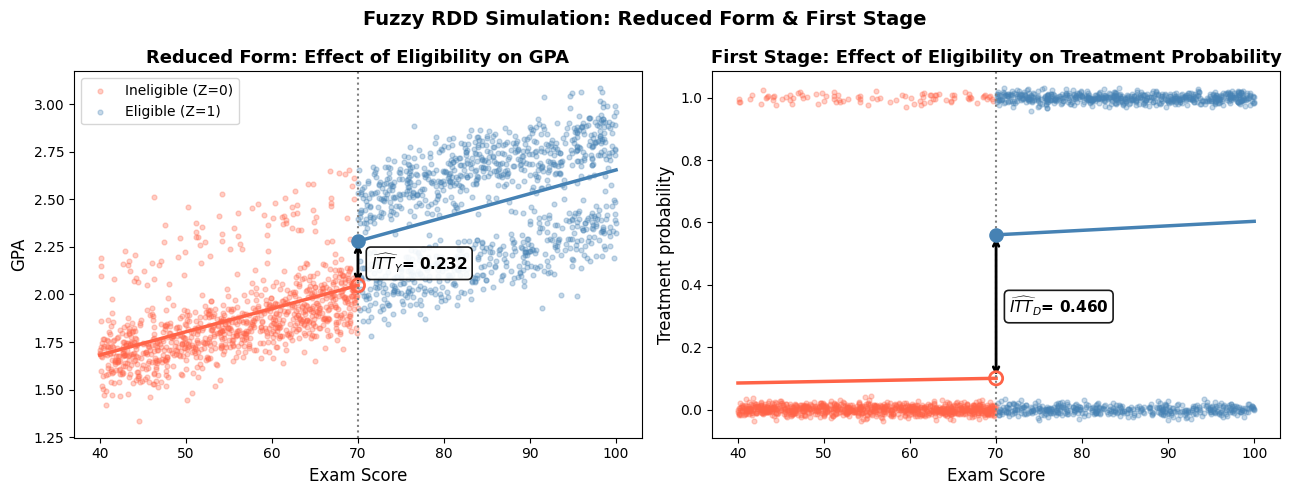

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: GPA scatter plot (Reduced form) ──
ax = axes[0]
left_  = df[df['elig'] == 0]
right_ = df[df['elig'] == 1]
ax.scatter(left_['score'],  left_['gpa'],  color='tomato',    alpha=0.3, s=12, label='Ineligible (Z=0)')
ax.scatter(right_['score'], right_['gpa'], color='steelblue', alpha=0.3, s=12, label='Eligible (Z=1)')

m_y_l = smf.ols('gpa ~ score_c', data=left_).fit()
m_y_r = smf.ols('gpa ~ score_c', data=right_).fit()
xs_l = np.linspace(40, cutoff, 100)
xs_r = np.linspace(cutoff, 100, 100)
ax.plot(xs_l, m_y_l.predict(pd.DataFrame({'score_c': xs_l - cutoff})), color='tomato',    lw=2.5)
ax.plot(xs_r, m_y_r.predict(pd.DataFrame({'score_c': xs_r - cutoff})), color='steelblue', lw=2.5)
y_l_gpa = m_y_l.params['Intercept']
y_r_gpa = m_y_r.params['Intercept']
ax.scatter([cutoff], [y_l_gpa], s=90, color='tomato',    zorder=6, facecolors='none', edgecolors='tomato', linewidths=2)
ax.scatter([cutoff], [y_r_gpa], s=90, color='steelblue', zorder=6)
ax.annotate('', xy=(cutoff, y_r_gpa), xytext=(cutoff, y_l_gpa),
            arrowprops=dict(arrowstyle='<->', color='black', lw=2))
ax.text(cutoff + 1.5, (y_l_gpa + y_r_gpa)/2,
        f'$\\widehat{{ITT}}_Y$= {y_r_gpa - y_l_gpa:.3f}', fontsize=11, fontweight='bold', va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', linewidth=1.2, alpha=0.9), zorder=7)
ax.axvline(cutoff, color='gray', ls=':', lw=1.5)
ax.set_title('Reduced Form: Effect of Eligibility on GPA', fontsize=13, fontweight='bold')
ax.set_xlabel('Exam Score', fontsize=12); ax.set_ylabel('GPA', fontsize=12)
ax.legend(fontsize=10)

# ── Right: Treatment probability (First stage) ──
ax2 = axes[1]
ax2.scatter(left_['score'],  left_['treated']  + np.random.normal(0, 0.012, len(left_)),  color='tomato',    alpha=0.3, s=12)
ax2.scatter(right_['score'], right_['treated'] + np.random.normal(0, 0.012, len(right_)), color='steelblue', alpha=0.3, s=12)

m_d_l = smf.ols('treated ~ score_c', data=left_).fit()
m_d_r = smf.ols('treated ~ score_c', data=right_).fit()
ax2.plot(xs_l, m_d_l.predict(pd.DataFrame({'score_c': xs_l - cutoff})), color='tomato',    lw=2.5)
ax2.plot(xs_r, m_d_r.predict(pd.DataFrame({'score_c': xs_r - cutoff})), color='steelblue', lw=2.5)
y_l_d = m_d_l.params['Intercept']
y_r_d = m_d_r.params['Intercept']
ax2.scatter([cutoff], [y_l_d], s=90, color='tomato',    zorder=6, facecolors='none', edgecolors='tomato', linewidths=2)
ax2.scatter([cutoff], [y_r_d], s=90, color='steelblue', zorder=6)
ax2.annotate('', xy=(cutoff, y_r_d), xytext=(cutoff, y_l_d),
             arrowprops=dict(arrowstyle='<->', color='black', lw=2))
ax2.text(cutoff + 1.5, (y_l_d + y_r_d)/2,
         f'$\\widehat{{ITT}}_D$= {y_r_d - y_l_d:.3f}', fontsize=11, fontweight='bold', va='center',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', linewidth=1.2, alpha=0.9), zorder=7)
ax2.axvline(cutoff, color='gray', ls=':', lw=1.5)
ax2.set_title('First Stage: Effect of Eligibility on Treatment Probability', fontsize=13, fontweight='bold')
ax2.set_xlabel('Exam Score', fontsize=12); ax2.set_ylabel('Treatment probability', fontsize=12)

plt.suptitle('Fuzzy RDD Simulation: Reduced Form & First Stage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# ── Compute LATE via Wald estimator ──
itt_y = y_r_gpa - y_l_gpa
itt_d = y_r_d   - y_l_d
late_wald = itt_y / itt_d

print("=" * 45)
print(f"  ITT_Y (Reduced form jump) : {itt_y:.4f}")
print(f"  ITT_D (First stage jump)  : {itt_d:.4f}")
print("-" * 45)
print(f"  Wald LATE = ITT_Y / ITT_D : {late_wald:.4f}")
print(f"  True LATE                  : {true_late}")
print("=" * 45)

  ITT_Y (Reduced form jump) : 0.2322
  ITT_D (First stage jump)  : 0.4601
---------------------------------------------
  Wald LATE = ITT_Y / ITT_D : 0.5048
  True LATE                  : 0.5


In [10]:
# ── Manual 2SLS ──
# 1st stage: D ~ Z + score_c + Z*score_c
fs = smf.ols('treated ~ elig + score_c + elig:score_c', data=df).fit()
df['D_hat'] = fs.fittedvalues

# F-statistic (t² for elig coefficient ≈ F)
f_stat = (fs.params['elig'] / fs.bse['elig']) ** 2

# 2nd stage: Y ~ D_hat + score_c + D_hat*score_c
ss = smf.ols('gpa ~ D_hat + score_c + D_hat:score_c', data=df).fit()

print("=" * 50)
print("  [1st Stage (First Stage)]")
print(f"  \u03b1\u2081 (Treatment probability jump)  : {fs.params['elig']:.4f}")
print(f"  F-statistic (\u226510 = strong IV): {f_stat:.1f}")
print()
print("  [2nd Stage (Second Stage)]")
print(f"  \u03b2\u2081 (LATE estimate)    : {ss.params['D_hat']:.4f}")
print(f"  True LATE           : {true_late}")
print("=" * 50)
print()
print("  * Standard errors require an IV package (e.g., linearmodels) for accuracy.")

  [1st Stage (First Stage)]
  α₁ (Treatment probability jump)  : 0.4601
  F-statistic (≥10 = strong IV): 166.7

  [2nd Stage (Second Stage)]
  β₁ (LATE estimate)    : 0.5047
  True LATE           : 0.5

  * Standard errors require an IV package (e.g., linearmodels) for accuracy.


## References

This notebook draws on the YouTube channel *인과추론의 데이터과학*'s RDD lecture materials and standard references on fuzzy regression discontinuity designs.

- **인과추론의 데이터과학**. Regression Discontinuity Design lecture video.  
  [https://www.youtube.com/watch?v=8SIoMJTmO3A](https://www.youtube.com/watch?v=8SIoMJTmO3A)

- **Imbens, G. W., & Lemieux, T. (2008)**. Regression discontinuity designs: A guide to practice. *Journal of Econometrics*, 142(2), 615-635.

- **Hahn, J., Todd, P., & Van der Klaauw, W. (2001)**. Identification and estimation of treatment effects with a regression-discontinuity design. *Econometrica*, 69(1), 201-209.

- **Card, D., Dobkin, C., & Maestas, N. (2008)**. The impact of nearly universal insurance coverage on health care utilization: Evidence from Medicare. *American Economic Review*, 98(5), 2242-2258.

- **Cattaneo, M. D., Idrobo, N., & Titiunik, R. (2019)**. *A Practical Introduction to Regression Discontinuity Designs*. Cambridge University Press.

